In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importe le csv des Tenracs et calcule leur nombre en avance
bd = pd.read_csv('./tenrac.csv')

In [2]:
groupementDoctrine = bd.groupby("doctrine")["idTenrac"] 
# pareil a print(bd['doctrine'].value_counts()) mais on utilisant la cle primaire idtenrac
groupement_par_doctrine = groupementDoctrine.count().sort_values(ascending=False)
print(groupement_par_doctrine)

doctrine
HERBOPHOBIE SACREE                   16631
CRUDIVEGISME                         16621
CULTE DU NAVET COSMIQUE              12966
EGLISE DU BROCOLI ETERNEL            10817
FOI CAROTICIENNE                      8693
ORDRE DE LA COURGETTE INTERDITE       7260
SECTE DU POIREAU MAUDIT               6307
TEMPLE DE L OIGNON PRIMORDIAL         5165
CONGREGATION DE L ARTICHAUT DIVIN     4253
MOUVEMENT ANTI-CHLOROPHYLLE           3434
MYSTICISME RACINAIRE                  2707
EGLISE UNIVERSELLE DU CHOU            2134
DOGME DE LA TOMATE HERETIQUE          1531
SCHISME DU RADIS NOIR                  992
ALLIANCE DES LEGUMOPHOBES DEVOTS       489
Name: idTenrac, dtype: int64


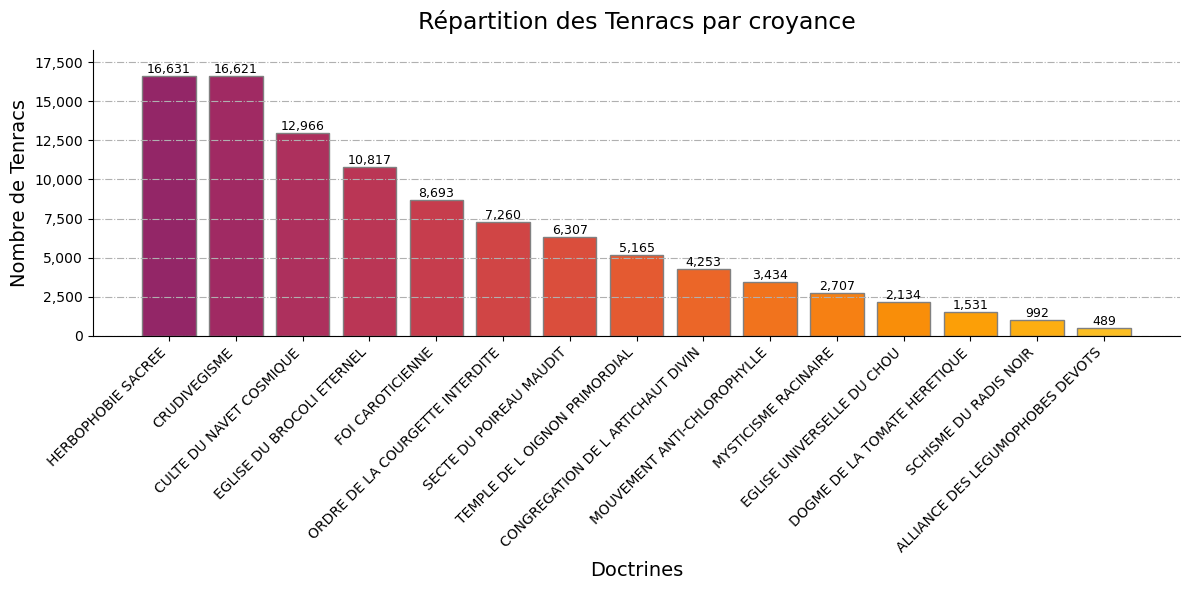

In [3]:
# Génère des couleurs uniformément depuis la palette "inferno"
couleur = plt.cm.inferno(np.linspace(0.4, 0.85,len(groupement_par_doctrine)))

# Crée la figure et les axes
fig, ax = plt.subplots(figsize=(12, 6))
# Dessine les barres : index = noms des grades, values = effectifs
bars = ax.bar(groupement_par_doctrine.index, groupement_par_doctrine.values, color=couleur, edgecolor='grey')

# Pour chaque barre, affiche le chiffre exact au-dessus
for bar, val in zip(bars, groupement_par_doctrine.values):
    ax.text(bar.get_x() + bar.get_width() / 2,  # centré horizontalement
            bar.get_height() + 1,                     # positionné en haut de la barre + un peu plus
            f'{val:,}',                           # séparateur milliers
            ha='center', va='bottom', fontsize=9)

ax.set_title('Répartition des Tenracs par croyance', fontsize=17, pad=15)
ax.set_xlabel('Doctrines', fontsize=14)
ax.set_ylabel('Nombre de Tenracs', fontsize=14)
# Ajoute de l'espace au-dessus de la barre la plus haute
ax.set_ylim(0, groupement_par_doctrine.max() * 1.1)

# Incline les villes à 35° alignées à droite
ax.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

# Formate l'axe Y avec des virgules
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Supprime les bordures du haut et de droite, plus joli
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajoute une grille en pointillés
ax.grid(axis='y', linestyle='-.')

# Ajuste les marges
plt.tight_layout()

plt.show()